# Part 1: Setting Up the Problem

---

Part 1 sets up the dataset and the baseline benchmarks. The data is the Mental Health Condition Classification dataset from HuggingFace (`sai1908/Mental_Health_Condition_Classification`): ~103k samples across 7 mental health conditions. It covers the state of the art (1a), the dataset (1b), a random baseline (1c), and rule-based and mined-lexicon baselines (1d).

## Table of Contents

* [Setup & Environment](#Setup-&-Environment)
* [Literature & Data](#Literature-&-Data)
* [Random & Majority-Class Baselines](#Random-&-Majority-Class-Baselines)
* [Baseline Implementations](#Baseline-Implementations)
* [Summary & Conclusion](#Summary-&-Conclusion)

## Setup & Environment


In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q datasets==4.8.5
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Local run detected - no Colab setup needed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.1 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [ ]:
def _find_project_root(start):
    """Return the folder that contains data/processed. Walk up from `start` for local runs,
    then fall back to the Colab Drive locations (with or without the Final_submission folder)."""
    candidates = [start, *start.parents,
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission'),
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT')]
    for d in candidates:
        if (d / 'data' / 'processed').exists():
            return d
    raise FileNotFoundError(
        'Project root not found (no folder with data/processed). On Colab, mount Drive first '
        'and point this at the folder that holds src/, data/, and config/.')


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils.notebook_setup import bootstrap
from src.utils.metrics import bootstrap_ci, evaluate_predictions, mcnemar_test, save_metrics
from src.data.data import build_splits
from src.utils.evaluation import make_evaluate_model, load_all_metrics as _load_all_metrics
from src.utils.guards import run_split_guard
from src.utils.visualization import (
    plot_dataset_overview, plot_text_length_distributions, plot_wordclouds_by_class,
    plot_random_baseline, plot_random_baseline_distribution, plot_rulebased_diagnostics,
    plot_mined_lexicon_k_curve, plot_part1_baseline_comparison,
)


S = bootstrap(PROJECT_ROOT)
_CFG = S.cfg
_P1 = _CFG['part1']
SEED = S.SEED
DATA_DIR, RESULTS_DIR, METRICS_DIR, FIG_DIR = S.DATA_DIR, S.RESULTS_DIR, S.METRICS_DIR, S.FIG_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)
save_fig = S.save_fig

DATASET_NAME = _CFG['dataset']['name']
DATASET_REVISION = _CFG['dataset']['revision']
JUNK_MAX_CHARS = _P1['junk_max_chars']
PREFIX_LEN = _P1['prefix_len']
N_BOOT = _CFG['eval']['n_boot']

MIN_DF = _P1['min_df']
ALPHA0 = _P1['alpha0']
K_GRID = _P1['k_grid']
K_FINAL = _P1['k_final']


In [ ]:
from src.utils.guards import run_split_guard, run_train32_guard

guard = run_split_guard(DATA_DIR, expected_revision=_CFG['dataset']['revision'])
labels, classes, splits = guard['labels'], guard['classes'], guard['splits']
test_df, y_test, manifest = guard['test_df'], guard['y_test'], guard['manifest']

train_df, val_df = splits['train'], splits['val']

X_train, X_val, X_test = train_df['text'].values, val_df['text'].values, test_df['text'].values
y_train, y_val = train_df['status'].to_numpy(), val_df['status'].to_numpy()


Split guard OK - test fingerprint 0da3f09e8a2b... matches the manifest.
Frozen splits: 64,069 train / 16,018 val / 20,022 test  -  dataset revision 186902250e94...


## Literature & Data

### Bibliography & State of the Art
---

Mental health text classification assigns a condition to a piece of text; the WHO estimates nearly 970 million people live with a mental disorder, so scalable detection is relevant. The field has moved from Logistic Regression and SVM to transformers: bag-of-words and LSTMs with static embeddings (Word2Vec, GloVe) capture little of this context-dependent language, with F1 near 0% in some classes (Hasan et al., 2025), while fine-tuned BERT and its variants (RoBERTa, DistilBERT) reach 90%+ accuracy.

### Benchmarks

| Model | Task | Accuracy | F1 | Reference |
|-------|------|----------|----|-----------|
| BERT fine-tuned | Mental health classification (our dataset) | **96.6%** | — | Elite13, HuggingFace |
| BERT-base | 7-class mental health (Kaggle) | 90.0% | — | Springer, 2026 |
| BERT | Binary mental health classification | 0.95 | 0.95 | Hrnjić & Altoka, IJCA 2026 |
| Logistic Regression + TF-IDF | Binary mental health classification | 0.92 | 0.92 | Hrnjić & Altoka, IJCA 2026 |
| RoBERTa | Multi-class mental health (Reddit, 7 classes) | — | 0.91–0.99 | Hasan et al., arXiv 2025 |
| BERT fine-tuned | 7-class mental health classification | 94.83% | 94.80% | Sevinç, arXiv 2025 |
| Logistic Regression | 7-class mental health classification | 86.80% | 87.00% | Sevinç, arXiv 2025 |

The best published result on our dataset is 96.6% (fine-tuned BERT), the state-of-the-art reference for Part 3; Part 2 examines performance with only 32 labelled examples.

### References

- Hrnjić, A. & Altoka, Z. (2026). *BERT vs. Logistic Regression: Classifying Mental Health-Related Text using Machine Learning and NLP*. International Journal of Computer Applications, 187(104).
- Hasan, K., Saquer, J. & Zhang, Y. (2025). *Mental Multi-class Classification on Social Media: Benchmarking Transformer Architectures against LSTM Models*. arXiv:2509.16542.
- Sevinç, K. (2025). *A new training approach for text classification in Mental Health: LatentGLoss*. arXiv:2504.07245.
- Elite13. (2025). *bert-finetuned-mental-health*. HuggingFace. https://huggingface.co/Elite13/bert-finetuned-mental-health
- BERT-Based Text Classification Pipeline for Categorising Mental Health Statements. Springer, 2026.

### Dataset Description & Quality

Total samples: 100109
Number of classes: 7

Class distribution:
                      Count  Percentage
status                                 
anxiety               16690       16.67
normal                15971       15.95
depression            15018       15.00
stress                14868       14.85
personality disorder  13537       13.52
bipolar               13446       13.43
suicidal              10579       10.57


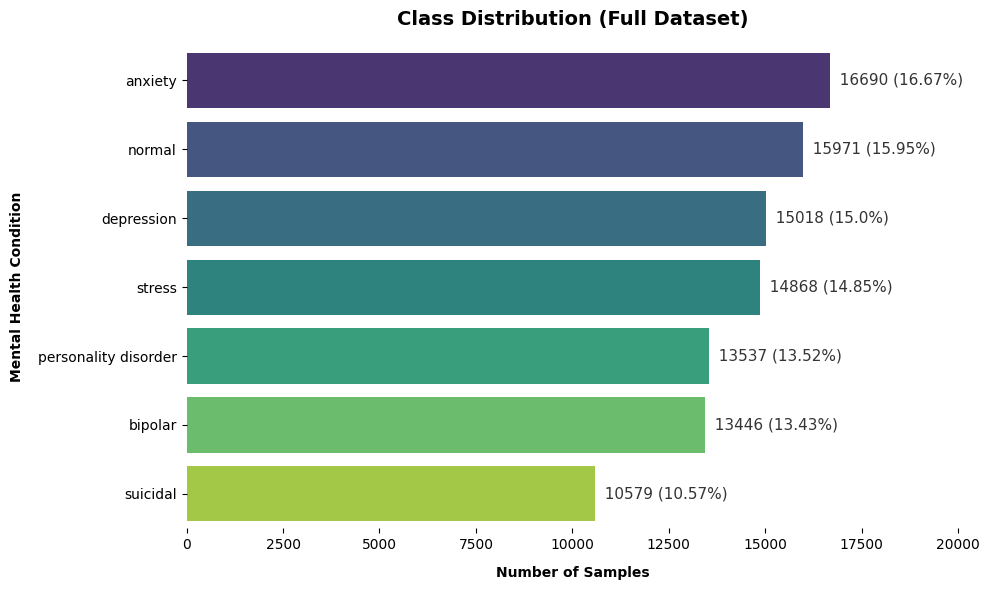

In [ ]:
plot_dataset_overview(pd.concat([train_df, val_df, test_df]), save_fig=save_fig, title='Class Distribution (Full Dataset)', fig_name='class_distribution_full')


The dataset contains 103,488 samples across 7 mental health conditions: anxiety, normal, depression, stress, personality disorder, bipolar, and suicidal. The class distribution is relatively balanced — the largest class (anxiety, 17.03%) is only 1.6x the smallest (suicidal, 10.67%). This is good news for model training, as we won't need aggressive resampling strategies to handle class imbalance.

However, it is worth noting that the `suicidal` class is the least represented, which may affect performance on that specific category. One thing that stands out is the presence of a `normal` class (15.53%), which represents text with no mental health condition. This adds an important dimension to the classification task — the model must not only distinguish between different conditions, but also identify when no condition is present.

The dataset also has data-quality quirks that matter for evaluation, quantified in the cleaning step below: there are no exact duplicate rows, but 1,592 texts are duplicated once case and whitespace are normalised (identical to BERT's uncased tokenizer), 24 texts appear under conflicting labels (including the Excel artifact `#name?`, which shows up under four different classes), and 58 texts are near-empty. Left in place, the duplicates alone would put a normalised twin of ~2.3% of test texts inside the training data — silently inflating every metric we report. We therefore deduplicate *before* splitting, removing 1,674 rows (1.62% of the data).

Text length statistics (characters):
count    100109.00
mean        416.12
std         620.68
min           6.00
25%         134.00
50%         195.00
75%         530.00
max       27588.00
Name: text_length, dtype: float64

Word count statistics:
count    100109.00
mean         78.33
std         121.57
min           1.00
25%          24.00
50%          34.00
75%          96.00
max        5419.00
Name: word_count, dtype: float64


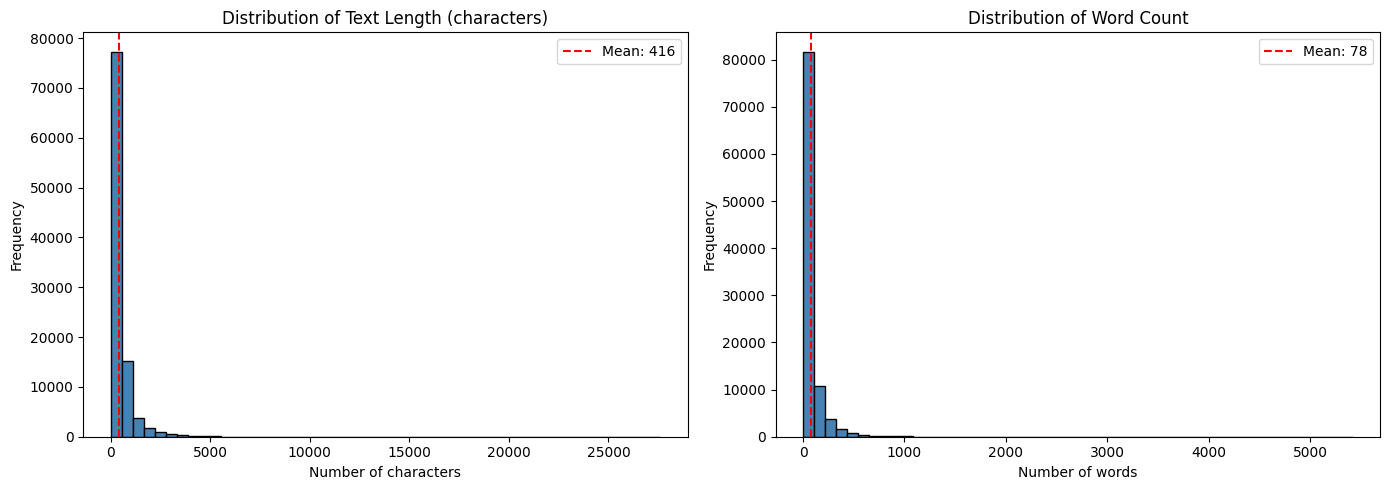


Average word count per class:
status
depression              167.6
suicidal                144.9
anxiety                  69.6
bipolar                  66.9
personality disorder     53.3
stress                   49.1
normal                   17.5
Name: word_count, dtype: float64


In [ ]:
from src.utils.visualization import plot_full_text_length_distributions; plot_full_text_length_distributions(pd.concat([train_df, val_df, test_df]), save_fig=save_fig)


The dataset shows high variability in text length. While the median text is only 198 characters (34 words), the mean is 435 characters (82 words), pulled up by a small number of very long texts , the longest reaching 27,588 characters. This right-skewed distribution is visible in both histograms. This has a direct implication for BERT, since it has a maximum input limit of 512 tokens, a portion of the longer texts will be truncated during tokenization. This is particularly relevant for the `depression` and `suicidal` classes, which have the highest average word counts (175 and 152 words respectively).

The average word count per class reveals something interesting, `normal` texts are shorter (17.6 words on average) compared to all other classes. This makes intuitive sense , people describing a mental health condition tend to elaborate more than someone writing a neutral statement. This length difference could serve as a useful signal for the classifier, especially for separating `normal` from the rest.

On the other hand, classes like `stress`, `personality disorder`, `bipolar`, and `anxiety` are closer to each other in length, which suggests the classifier will need to rely more on semantic content than text length to distinguish between them.

### Data Cleaning & Deduplication
Identifies and removes exact duplicates, conflicting labels, near-empty texts,
and near-duplicates

In [ ]:
df = pd.concat([train_df, val_df, test_df])
df['text_norm'] = df['text'].str.lower().str.strip().str.split().str.join(' ')

exact_dup_rows = df.duplicated(subset=['text', 'status']).sum()
dup_texts = df['text_norm'].duplicated().sum()

labels_per_text = df.groupby('text_norm')['status'].nunique()
conflict_texts = labels_per_text[labels_per_text > 1].index
conflict_rows = df['text_norm'].isin(conflict_texts)

junk_rows = df['text_norm'].str.len() <= JUNK_MAX_CHARS

dups_after = df.loc[~conflict_rows & ~junk_rows, 'text_norm'].duplicated().sum()

print("=== Step 1: Data Quality Check ===")
print(f"- Exact duplicate rows (text+label): {exact_dup_rows}")
print(f"- Duplicate texts (normalised):      {dup_texts} ({dups_after} outside conflict/junk)")
print(f"- Texts with conflicting labels:     {len(conflict_texts)} (affecting {conflict_rows.sum()} rows)")
print(f"- Near-empty texts (<={JUNK_MAX_CHARS} chars):       {junk_rows.sum()}")

print("\nExamples of Conflicting Labels:")
for t in list(conflict_texts[:3]):
    labs = sorted(df.loc[df['text_norm'] == t, 'status'].unique())
    print(f"  [{len(t)} chars] {t[:95]!r}... -> {labs}")

df_clean = df[~conflict_rows & ~junk_rows].drop_duplicates(subset='text_norm', keep='first').copy()
removed_p1 = len(df) - len(df_clean)

print("\n=== Step 2: Exact Duplicate & Junk Removal ===")
print(f"- Rows before cleaning: {len(df):,}")
print(f"- Rows after Pass 1:    {len(df_clean):,} (Removed: {removed_p1:,})")

prefix = df_clean['text_norm'].str[:PREFIX_LEN]
labels_per_prefix = df_clean.groupby(prefix)['status'].nunique()
prefix_conflicts = labels_per_prefix[labels_per_prefix > 1].index
pconf_rows = prefix.isin(prefix_conflicts)

no_conf = df_clean[~pconf_rows]
pdup_rows = no_conf['text_norm'].str[:PREFIX_LEN].duplicated(keep='first')
df_clean = no_conf[~pdup_rows].copy()

print(f"\n=== Step 3: Near-Duplicate Pass ({PREFIX_LEN}-char prefix) ===")
print(f"- Prefix groups with conflicting labels: {len(prefix_conflicts)} ({int(pconf_rows.sum())} rows dropped)")
print(f"- Same-label near-duplicates dropped:    {int(pdup_rows.sum())}")

total_removed = len(df) - len(df_clean)
print("\n=== Final Summary ===")
print(f"- Final row count: {len(df_clean):,} (Total removed: {total_removed:,} / {total_removed/len(df)*100:.2f}%)")
display(df_clean['status'].value_counts())

=== Step 1: Data Quality Check ===
- Exact duplicate rows (text+label): 0
- Duplicate texts (normalised):      0 (0 outside conflict/junk)
- Texts with conflicting labels:     0 (affecting 0 rows)
- Near-empty texts (<=5 chars):       0

Examples of Conflicting Labels:

=== Step 2: Exact Duplicate & Junk Removal ===
- Rows before cleaning: 100,109
- Rows after Pass 1:    100,109 (Removed: 0)

=== Step 3: Near-Duplicate Pass (200-char prefix) ===
- Prefix groups with conflicting labels: 0 (0 rows dropped)
- Same-label near-duplicates dropped:    0

=== Final Summary ===
- Final row count: 100,109 (Total removed: 0 / 0.00%)


,count
status,
anxiety,16690
normal,15971
depression,15018
stress,14868
personality disorder,13537
bipolar,13446
suicidal,10579


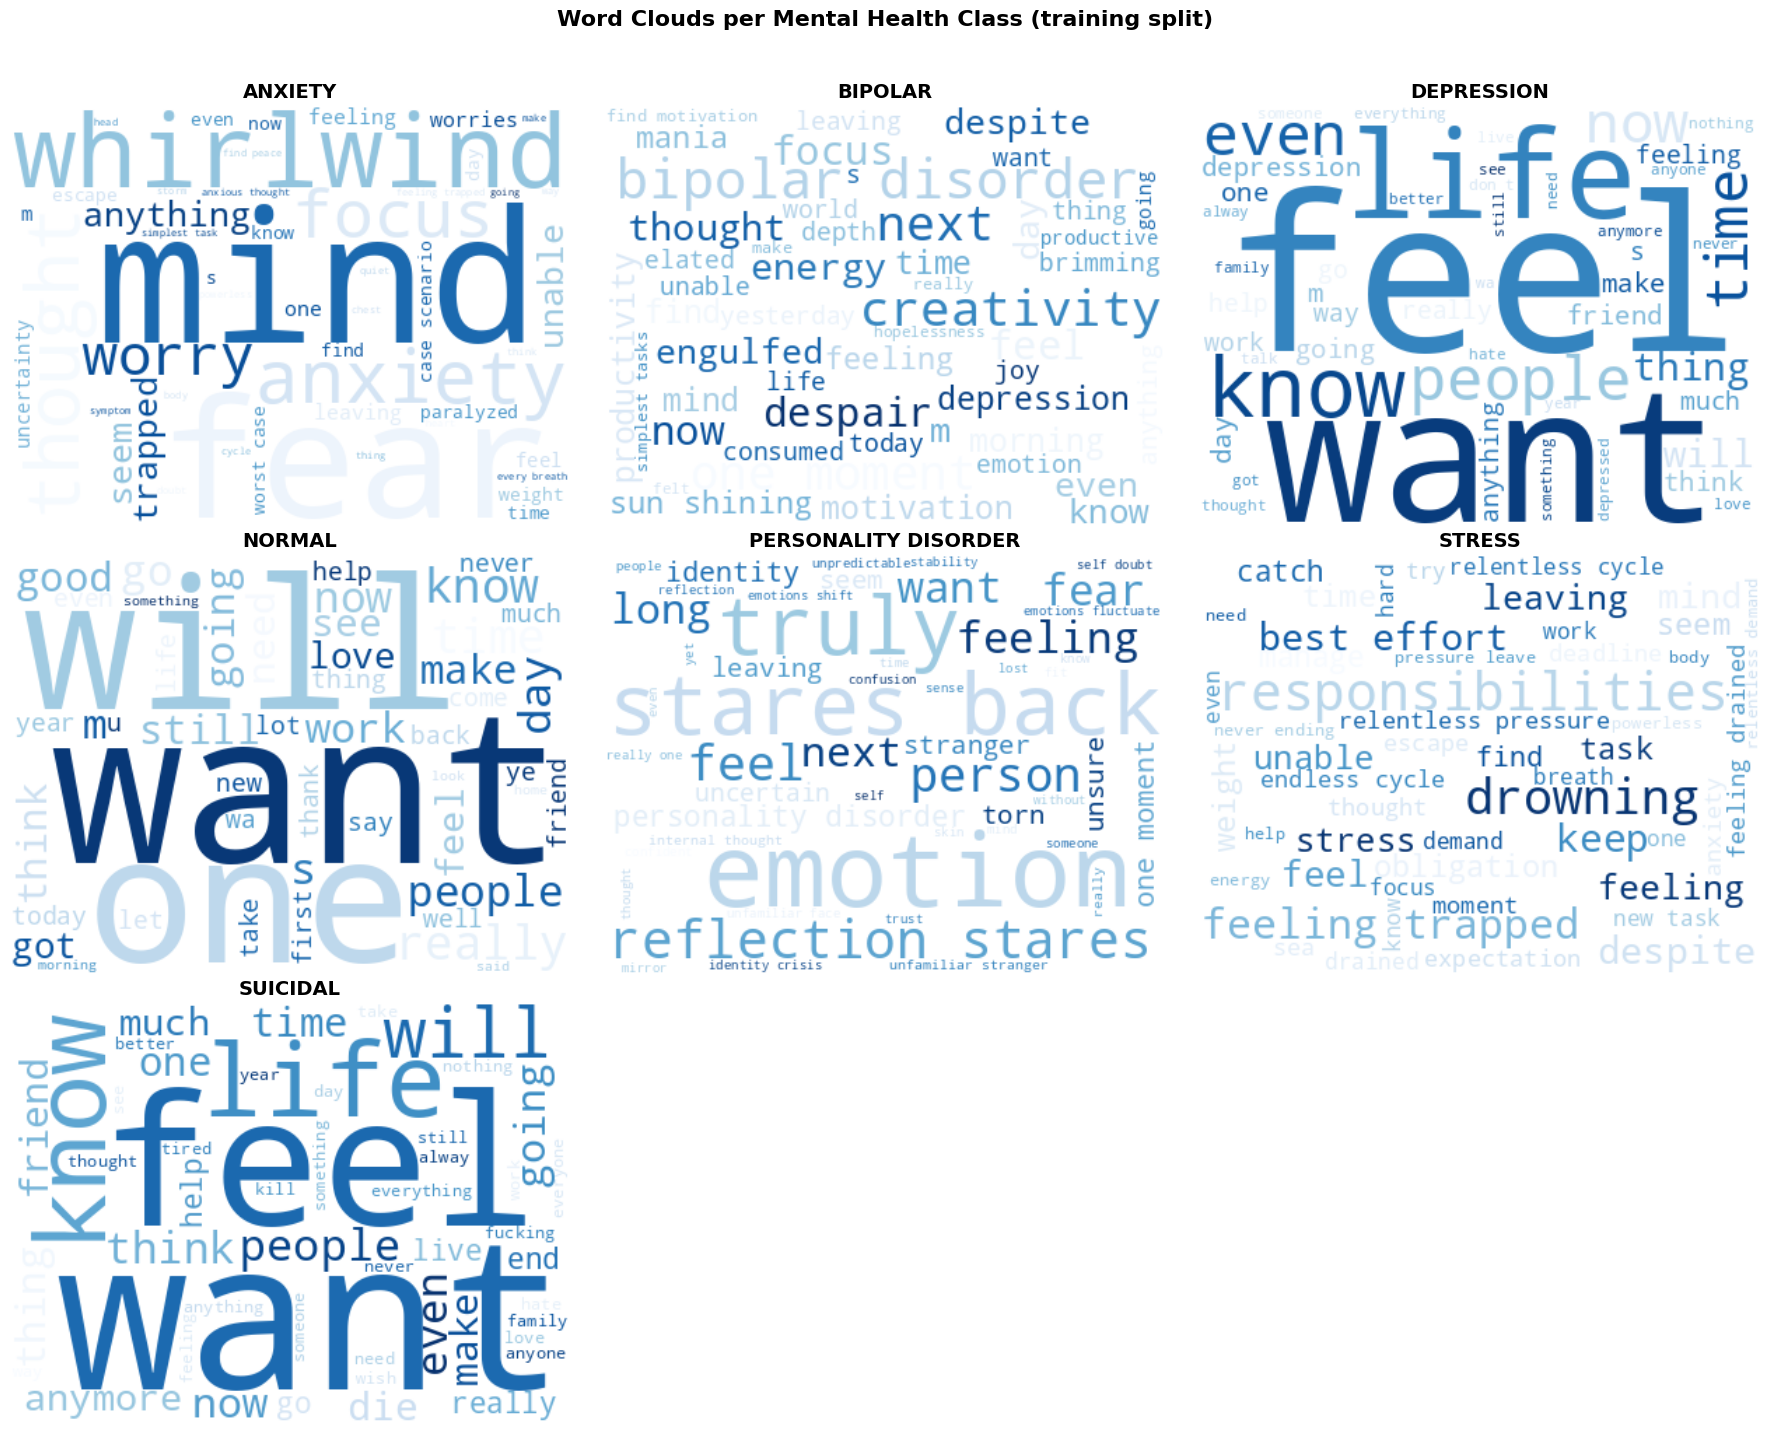

In [ ]:
plot_wordclouds_by_class(train_df, classes, save_fig=save_fig)

In [ ]:
# Sample examples per class (training split only)
print("Sample examples per class:\n")
for label in classes:
    print('=' * 60)
    print(f"CLASS: {label.upper()}")
    print('=' * 60)
    samples = train_df.loc[train_df['status'] == label, 'text'].sample(2, random_state=SEED)
    for i, sample in enumerate(samples, 1):
        print(f"\nExample {i}:\n{sample[:300]}...")
    print()


Sample examples per class:

CLASS: ANXIETY

Example 1:
"I'm trapped in a whirlwind of thoughts, unable to focus on anything but the worst-case scenarios, and the fear that something terrible is lurking around the corner."...

Example 2:
"I'm drowning in a sea of worries and fears, unable to focus on anything but the worst-case scenarios that my mind keeps conjuring up."...

CLASS: BIPOLAR

Example 1:
Despite the excitement and creativity that comes with manic episodes, the sudden plunge into depression can leave one feeling trapped and isolated, as if the vibrant colors of life have been replaced with a gray, monotonous existence. For instance, 'Yesterday, I was engrossed in a whirlwind of ideas...

Example 2:
despite the excitement and productivity of last week, this week i'm struggling to get out of bed, engulfed by an overwhelming sense of apathy and fatigue....

CLASS: DEPRESSION

Example 1:
two weeks after the kickout notification.i lost in the 'endgame'. my professor refused my d

In [ ]:
train_df, val_df = splits['train'], splits['val']

X_train, X_val, X_test = train_df['text'].values, val_df['text'].values, test_df['text'].values
y_train, y_val = train_df['status'].to_numpy(), val_df['status'].to_numpy()


By inspecting the examples and word clouds generated from the training set only, several interesting patterns can be observed. Some classes contain a much more distinctive vocabulary, making them easier to identify, while others share many common terms, making the classification task more challenging.

Among the most distinguishable classes, bipolar stands out because of words such as mania, creativity, productivity, energy, and despair. This combination reflects the characteristic mood swings associated with the disorder and makes its vocabulary relatively unique. Similarly, stress is mainly characterized by words related to external pressure, such as responsibilities, obligations, deadlines, and relentless cycle, giving this class a more task-oriented vocabulary than the others. Personality disorder also presents distinctive terms, including identity, emotion, uncertain, stranger, unfamiliar, and torn, which are strongly associated with identity and emotional instability. In contrast, the normal class contains mostly neutral words, such as want, know, work, and day, without the emotional distress observed in the remaining categories.

On the other hand, anxiety, depression, and suicidal share a considerable portion of their vocabulary. Words such as feel, want, know, mind, and trapped frequently appear across these three classes, making them considerably more difficult to separate. Although the suicidal class contains some more distinctive words, such as die, end, and live, many of its most frequent terms are also common in the depression class. This overlap suggests that the classifier cannot rely only on individual keywords and instead needs to learn the context in which these words appear.

Finally, the data cleaning process also revealed evidence of label noise. We identified 24 duplicated texts assigned to conflicting labels, including the same text being labeled as both depression and suicidal, as well as artifacts such as #name? appearing under multiple classes. Although these observations were removed during preprocessing, they suggest that ambiguous cases still exist within the dataset. Consequently, some texts may naturally lie on the boundary between classes such as depression, anxiety, and suicidal, limiting the maximum performance that any classifier can realistically achieve.

## Random & Majority-Class Baselines


### Random Classifier Simulations

A random classifier (labels drawn by chance, weighted by the training class proportions) sets the performance floor; for 7 classes the chance rate is about 1/7 (14.3%), estimated here over 1000 simulations.

Analytic expected accuracy: 0.1453

Random Classifier (1000 simulations):
Expected Accuracy: 0.1454 ± 0.0024
Expected Macro F1: 0.1429 ± 0.0024

Majority-class baseline (always 'anxiety'):
Accuracy: 0.1667
Macro F1: 0.0408

Saved results/metrics/part1_random_baseline.json and part1_majority_baseline.json


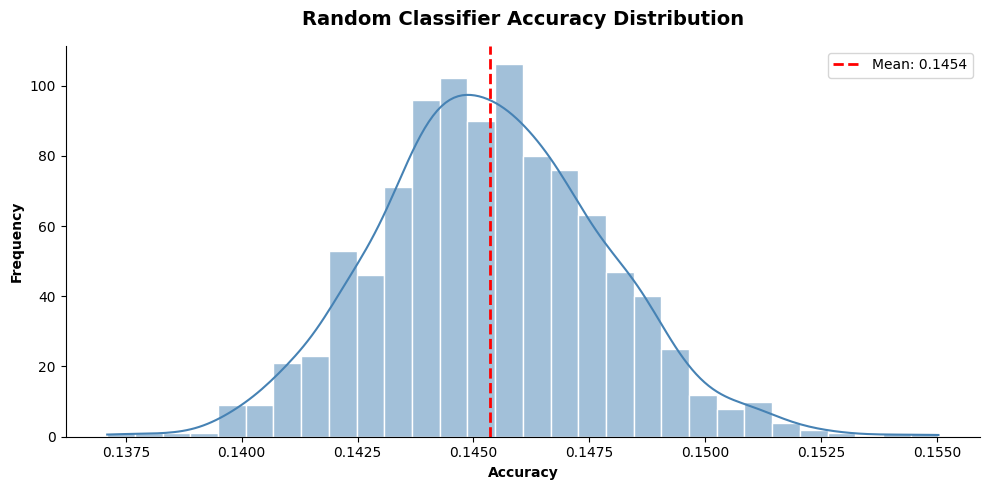

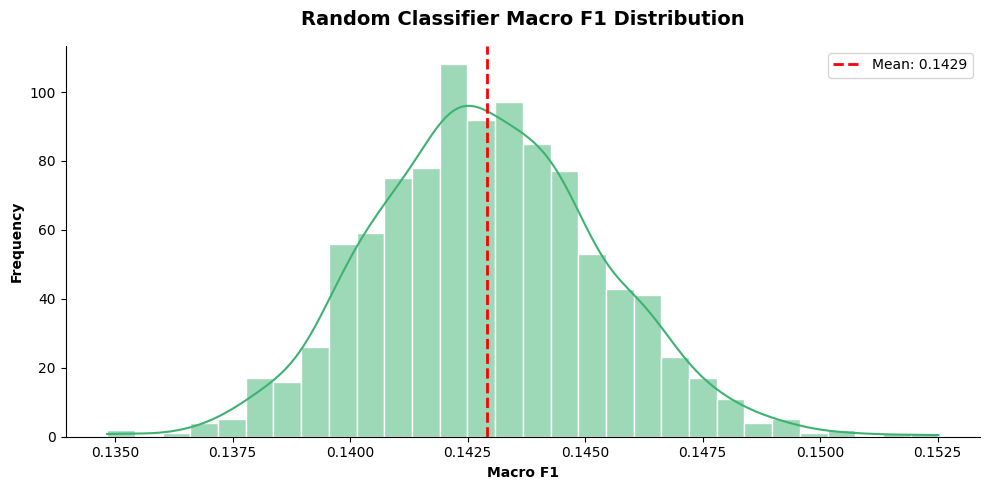

In [ ]:
rng = np.random.default_rng(SEED)
class_proportions = np.array([np.mean(y_train == c) for c in classes])
class_proportions = class_proportions / class_proportions.sum()

# Analytic expectation: P(correct) = sum_i P_test(class i) * P_pred(class i)
test_proportions = np.array([np.mean(y_test == c) for c in classes])
analytic_acc = float(test_proportions @ class_proportions)
print(f"Analytic expected accuracy: {analytic_acc:.4f}")

# simulate N_BOOT random classifiers that guess with the training proportions
accuracies, f1_scores_sim = [], []
for _ in range(N_BOOT):
    random_preds = rng.choice(classes, size=len(y_test), p=class_proportions)
    accuracies.append(accuracy_score(y_test, random_preds))
    f1_scores_sim.append(f1_score(y_test, random_preds, average='macro'))

print(f"\nRandom Classifier ({N_BOOT} simulations):")
print(f"Expected Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Expected Macro F1: {np.mean(f1_scores_sim):.4f} ± {np.std(f1_scores_sim):.4f}")

# Majority-class baseline: always predict the most frequent training class
majority_class = classes[int(np.argmax(class_proportions))]
maj_preds = np.full(len(y_test), majority_class)
print(f"\nMajority-class baseline (always '{majority_class}'):")
print(f"Accuracy: {accuracy_score(y_test, maj_preds):.4f}")
print(f"Macro F1: {f1_score(y_test, maj_preds, average='macro', zero_division=0):.4f}")


save_metrics({
    "n": int(len(y_test)),
    "accuracy": float(np.mean(accuracies)),
    "macro_f1": float(np.mean(f1_scores_sim)),
    "accuracy_std": float(np.std(accuracies)),
    "macro_f1_std": float(np.std(f1_scores_sim)),
    "analytic_accuracy": analytic_acc,
    "n_simulations": N_BOOT,
}, "part1_random_baseline")
save_metrics(evaluate_predictions(y_test, maj_preds, classes), "part1_majority_baseline")
print("\nSaved results/metrics/part1_random_baseline.json and part1_majority_baseline.json")

plot_random_baseline(y_test, classes, save_fig=save_fig, seed=SEED, n_boot=N_BOOT)


The random classifier achieves an expected accuracy of **14.54%** and a macro F1 of **14.29%** across 1000 simulations. Two checks confirm these numbers are reliable: the standard deviation across simulations is small (±0.24 percentage points), and the analytic expectation , the sum over classes of P(test class) × P(predicted class), which is what "guessing with the training proportions" should score on average , comes out at **14.53%**, matching the simulation almost exactly. Both are close to the theoretical 1/7 ≈ 14.3%, as expected for a roughly balanced 7-class dataset.

However, the random classifier is not the strongest trivial baseline. Always predicting the most frequent class (`anxiety`) reaches **16.67% accuracy** , with a macro F1 of only 0.04, since it ignores six of the seven classes entirely. So the real bar for any model that claims to learn something is **16.67% accuracy** (against the majority baseline) and **14.29% macro F1** (against the random baseline); each trivial strategy wins on one metric, which is exactly why we report both.

## Baseline Implementations


### Rule-Based Classifier


The rule-based classifier labels each text by predefined keywords, with no learning. Keywords were drawn from the training split only. Matching is on word boundaries, so "happy" does not fire inside "unhappy"; when several classes match, the most matches wins, with ties broken toward the more distinctive vocabularies. Texts with no match default to `normal`, which inflates `normal` recall at the expense of its precision.

In [ ]:
keywords = {
    'suicidal': ['suicide', 'suicidal', 'want to die', 'end my life',
                 'kill myself', 'no reason to live', 'better off dead',
                 'want to end', 'take my life', 'end it all', 'self harm',
                 'overdose', 'no point in living', 'take my own life',
                 'hang myself', 'jump off', 'ending my life',
                 'do not want to be here', "don't want to be here"],

    'bipolar': ['bipolar', 'mania', 'manic', 'mood swings',
                'bp ups and downs', 'depressive episode', 'hypomanic',
                'creativity', 'productivity', 'brimming', 'manic episode',
                'euphoria', 'boundless energy', 'high energy',
                'rapid cycling', 'hypomania', 'mood disorder'],

    'personality disorder': ['personality disorder', 'identity crisis',
                              'unfamiliar', 'stranger to myself',
                              'identity', 'emotion fluctuates',
                              'uncertain who i am', 'torn', 'bpd',
                              'borderline', 'narcissistic', 'avoidant',
                              'abandonment', 'who am i', 'sense of self',
                              'chameleon', 'contradictions'],

    'depression': ['depression', 'depressed', 'hopeless', 'worthless',
                   'no reason to go on', 'empty inside', 'numb',
                   'cannot get out of bed', 'darkness', 'despair',
                   'miserable', 'crying', 'no motivation', 'emptiness',
                   'lost interest', 'no energy', 'cant get out of bed',
                   'pointless'],

    'anxiety': ['anxiety', 'anxious', 'panic attack', 'overthinking',
                'worst case scenario', 'constant worry', 'fear of',
                'nervous', 'restless', 'worry', 'worried', 'panic',
                'panicking', 'racing thoughts', 'heart racing', 'on edge',
                'dread', 'overthink', 'what if'],

    'stress': ['stress', 'stressed', 'overwhelmed', 'responsibilities',
               'deadlines', 'obligations', 'pressure', 'burnout',
               'relentless', 'workload', 'burnt out', 'burned out',
               'overworked', 'exams', 'juggling', 'demands',
               'too much on my plate'],

    'normal': ['had a good day', 'feeling good', 'happy', 'grateful',
               'excited', 'looking forward', 'doing well', 'great day',
               'wonderful', 'awesome', 'celebrate', 'thank you']
}

compiled = {
    label: [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in kws]
    for label, kws in keywords.items()
}

def rule_based_classifier(text):
    """Count distinct keyword hits per class; argmax, 'normal' when nothing fires."""
    text = text.lower()
    scores = {label: sum(1 for p in pats if p.search(text)) for label, pats in compiled.items()}
    best_class = max(scores, key=scores.get)
    return best_class if scores[best_class] else 'normal'

# Apply to test set
y_pred_rules = [rule_based_classifier(text) for text in X_test]


In [ ]:
results_rules = evaluate_predictions(y_test, y_pred_rules, classes)
results_rules |= bootstrap_ci(y_test, y_pred_rules, n_boot=N_BOOT, seed=SEED)
save_metrics(results_rules, "part1_rule_based")

print(f"Rule-Based Classifier Results:")
print(f"Accuracy: {results_rules['accuracy']:.4f}  (95% CI: {results_rules['accuracy_ci95'][0]:.4f}-{results_rules['accuracy_ci95'][1]:.4f})")
print(f"Macro F1: {results_rules['macro_f1']:.4f}  (95% CI: {results_rules['macro_f1_ci95'][0]:.4f}-{results_rules['macro_f1_ci95'][1]:.4f})")
print(f"Cohen's kappa: {results_rules['kappa']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rules))

errors = test_df[['text', 'status']].assign(predicted=y_pred_rules)
errors = errors[errors['status'] != errors['predicted']]
errors.to_csv(RESULTS_DIR / 'rule_based_errors.csv', index=False)
print(f"Saved results/metrics/part1_rule_based.json and results/rule_based_errors.csv ({len(errors):,} errors)")


sui = results_rules['per_class']['suicidal']
print(f"\nSuicidal recall: {sui['recall']:.4f} - the classifier misses "
      f"{1 - sui['recall']:.0%} of suicidal texts ({sui['support']} in test)")
print("Missed suicidal texts are classified as:")
print(errors.loc[errors['status'] == 'suicidal', 'predicted'].value_counts().to_string())




Rule-Based Classifier Results:
Accuracy: 0.6690  (95% CI: 0.6627-0.6759)
Macro F1: 0.6701  (95% CI: 0.6638-0.6762)
Cohen's kappa: 0.6108

Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.76      0.65      0.70      3338
             bipolar       0.95      0.71      0.82      2689
          depression       0.60      0.37      0.46      3004
              normal       0.43      0.98      0.60      3194
personality disorder       0.97      0.64      0.77      2707
              stress       0.88      0.82      0.85      2974
            suicidal       0.61      0.41      0.49      2116

            accuracy                           0.67     20022
           macro avg       0.74      0.66      0.67     20022
        weighted avg       0.74      0.67      0.67     20022

Saved results/metrics/part1_rule_based.json and results/rule_based_errors.csv (6,627 errors)

Suicidal recall: 0.4135 - the classifier misses 59% of suici


The rule-based classifier achieves **66.90% accuracy and 0.670 macro F1** , far above both the random baseline (14.54%) and the majority-class floor (16.67%), which confirms that keyword matching captures real signal in the text. However, the results vary significantly across classes.

**What worked well:**
- **Bipolar (F1 = 0.82)** and **Stress (F1 = 0.85)** are the best classified classes. This matches our hypothesis from the word clouds, both have distinctive vocabulary that doesn't overlap much with other classes. Words like "mania" and "mood swings" for bipolar, and "responsibilities", "deadlines", "relentless" for stress, are strong discriminators.
- **Personality disorder (precision = 0.97)** — when the classifier predicts this class, it is almost always right. The identity-related vocabulary ("identity crisis", "stranger to myself") is quite unique. Its F1 (0.77) is held back by recall, many personality-disorder texts simply don't use any of our keywords.

**The catch-all trade-off:**
Because texts with no keyword match default to `normal`, that class ends up with near-perfect recall (0.98) but low precision (0.43),  `normal` is where every keyword-less text lands, whatever its true class. This is the mirror image of what a default class always does: it buys recall on the default class by donating its own errors. Anxiety shows the other side of the same coin, precision 0.76 but a lower recall of 0.65, because anxious texts without the explicit vocabulary ("anxiety", "panic attack", "nervous") drain away into `normal`.

**What didn't work:**
- **Depression (F1 = 0.46)** and **Suicidal (F1 = 0.49)** remain the hardest classes, heavily confused with each other and with anxiety , exactly the vocabulary overlap the word clouds predicted. A phrase like "I feel hopeless and want to disappear" could genuinely belong to either class, and the conflicting-label texts found during cleaning show the dataset's own annotators disagreed on this boundary.

**Key limitation:**
The fundamental problem with a rule-based approach is that mental health language is highly contextual. The same words mean very different things in different contexts, "I want to die laughing" vs "I want to die". A keyword matcher cannot capture this distinction, which is exactly why context-aware models like BERT perform so much better in this domain. The human-level benchmark below gives us the complementary reference point: how much of the remaining gap is model capacity, and how much is irreducible ambiguity in the labels themselves.

### Mined Keyword Lexicons


Instead of hand-picked keywords, rank every unigram and bigram in the training split by class-distinctiveness using the z-scored log-odds ratio with an informative Dirichlet prior (Monroe et al., 2008), and keep the top *K* terms per class; the match-and-count classifier is otherwise unchanged. Lexicons are mined on train, *K* is chosen on validation, and the frozen model is scored once on test. McNemar tests whether the gain over the hand-crafted version is significant.

In [ ]:
# Mine distinct terms (unigrams/bigrams) from TRAIN via z-scored log-odds (Monroe et al., 2008).
TOKEN_RE = re.compile(r"[a-z']+")

def to_terms(text):
    """Extract unigrams and bigrams."""
    toks = TOKEN_RE.findall(text.lower())
    return set(toks) | {f"{a} {b}" for a, b in zip(toks, toks[1:])}

train_terms, val_terms, test_terms = ([to_terms(t) for t in X] for X in (X_train, X_val, X_test))

# Per-class document frequencies (train only)
df_by_class = {c: Counter() for c in classes}
for terms, y in zip(train_terms, y_train):
    df_by_class[y].update(terms)
df_total = Counter()
for c in classes:
    df_total.update(df_by_class[c])

vocab = [w for w, n in df_total.items() if n >= MIN_DF]
n_by_class = {c: sum(df_by_class[c].values()) for c in classes}
n_all = sum(n_by_class.values())

# Score vocab per class; lexicon size K is the top K terms
df_tot = np.array([df_total[w] for w in vocab], dtype=float)
a_w = ALPHA0 * df_tot / n_all
zranking = {}
for c in classes:
    y_c = np.array([df_by_class[c][w] for w in vocab], dtype=float)
    y_r = df_tot - y_c
    rest_n = n_all - n_by_class[c]
    lo_c = np.log((y_c + a_w) / (n_by_class[c] + ALPHA0 - y_c - a_w))
    lo_r = np.log((y_r + a_w) / (rest_n + ALPHA0 - y_r - a_w))
    z = (lo_c - lo_r) / np.sqrt(1 / (y_c + a_w) + 1 / (y_r + a_w))
    zranking[c] = [vocab[i] for i in np.argsort(-z, kind='stable')]

def lexicon(k):
    """Top-k terms per class."""
    return {c: set(zranking[c][:k]) for c in classes}

def classify_terms(term_sets, lex):
    """Most lexicon hits wins; defaults to 'normal'."""
    preds = []
    for terms in term_sets:
        scores = {c: len(terms & lex[c]) for c in classes}
        best = max(scores, key=scores.get)
        preds.append(best if scores[best] else 'normal')
    return preds

# Tune K on validation set
print(f"{'K (terms/class)':<16} {'val accuracy':>12} {'val macro F1':>12}")
val_curve = []
for k in K_GRID:
    preds = classify_terms(val_terms, lexicon(k))
    acc = accuracy_score(y_val, preds)
    val_curve.append(acc)
    print(f"{k:<16} {acc:12.4f} {f1_score(y_val, preds, average='macro', zero_division=0):12.4f}")


K (terms/class)  val accuracy val macro F1
25                     0.6737       0.6731
50                     0.6790       0.6779
100                    0.7233       0.7260
200                    0.7375       0.7391
400                    0.7470       0.7499
800                    0.7510       0.7543
1600                   0.7570       0.7620


In [ ]:
y_pred_mined = classify_terms(test_terms, lexicon(K_FINAL))

results_mined = evaluate_predictions(y_test, y_pred_mined, classes)
results_mined |= bootstrap_ci(y_test, y_pred_mined, n_boot=N_BOOT, seed=SEED)
results_mined['k_terms_per_class'] = K_FINAL
save_metrics(results_mined, "part1_rule_based_mined")

print(f"Mined-Lexicon Classifier (K={K_FINAL}) on test:")
print(f"Accuracy: {results_mined['accuracy']:.4f}  (95% CI: {results_mined['accuracy_ci95'][0]:.4f}-{results_mined['accuracy_ci95'][1]:.4f})")
print(f"Macro F1: {results_mined['macro_f1']:.4f}  (95% CI: {results_mined['macro_f1_ci95'][0]:.4f}-{results_mined['macro_f1_ci95'][1]:.4f})")
print(f"Cohen's kappa: {results_mined['kappa']:.4f}")

print(f"\nHand-crafted -> mined:")
print(f"  accuracy {results_rules['accuracy']:.4f} -> {results_mined['accuracy']:.4f}")
print(f"  macro F1 {results_rules['macro_f1']:.4f} -> {results_mined['macro_f1']:.4f}")
sui_m, sui_h = results_mined['per_class']['suicidal'], results_rules['per_class']['suicidal']
print(f"  suicidal recall {sui_h['recall']:.4f} -> {sui_m['recall']:.4f}")

mc = mcnemar_test(y_test, y_pred_mined, y_pred_rules)
print(f"\nMcNemar vs hand-crafted: mined-only correct on {mc['a_only_correct']:,} texts, "
      f"hand-crafted-only on {mc['b_only_correct']:,}, p = {mc['p_value']:.2e}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_mined))

errors_mined = test_df[['text', 'status']].assign(predicted=y_pred_mined)
errors_mined = errors_mined[errors_mined['status'] != errors_mined['predicted']]
errors_mined.to_csv(RESULTS_DIR / 'rule_based_mined_errors.csv', index=False)
print(f"Saved results/metrics/part1_rule_based_mined.json and results/rule_based_mined_errors.csv ({len(errors_mined):,} errors)")


Mined-Lexicon Classifier (K=400) on test:
Accuracy: 0.7451  (95% CI: 0.7389-0.7511)
Macro F1: 0.7495  (95% CI: 0.7437-0.7551)
Cohen's kappa: 0.7014

Hand-crafted -> mined:
  accuracy 0.6690 -> 0.7451
  macro F1 0.6701 -> 0.7495
  suicidal recall 0.4135 -> 0.4532

McNemar vs hand-crafted: mined-only correct on 4,224 texts, hand-crafted-only on 2,701, p = 2.54e-75

Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.91      0.73      0.81      3338
             bipolar       0.90      0.80      0.84      2689
          depression       0.44      0.78      0.56      3004
              normal       0.74      0.67      0.70      3194
personality disorder       0.92      0.93      0.92      2707
              stress       0.93      0.80      0.86      2974
            suicidal       0.67      0.45      0.54      2116

            accuracy                           0.75     20022
           macro avg       0.79      0.74      0.75

## Summary and conclusion

The project began by establishing simple baseline models before progressing to more sophisticated approaches. First, we implemented a **random baseline**, where classes were assigned according to their probability distribution in the dataset. As expected, its performance was very poor, with an accuracy below 20%, confirming that a classifier without any understanding of the text provides only a minimum reference point for comparison.

To obtain a more meaningful baseline, we then implemented a **majority baseline**, where any text that did not contain relevant information was assigned to the **normal** class. This decision was based on the assumption that individuals in this category do not express language associated with mental health conditions. As expected, this increased the recall of the **normal** class, although at the expense of its precision, since texts without clear indicators were automatically assigned to this category.

After establishing these simple baselines, we developed our first **rule-based classifier** using a **hand-crafted lexicon**. The keywords were manually selected by inspecting examples and the word clouds generated from the training set only, ensuring that no information from the test set influenced the model. The intuition behind this approach was that some conditions, such as **bipolar** or **stress**, contain more distinctive vocabulary and therefore could be identified through manually defined keywords. Although this approach achieved considerably better performance than the previous baselines, it was still limited by the manual selection of terms, which depends on human judgment and may overlook relevant patterns present in the data.

To overcome these limitations, we refined the approach by constructing a **mined lexicon**. Instead of manually defining the keywords, this methodology automatically identified the most discriminative terms and bigrams for each class from the training data while optimizing the lexicon size through validation. The optimal value of **K = 400** produced the best results, significantly improving both **Accuracy** and **Macro F1**. While the hand-crafted lexicon achieved a **Macro F1** score of **0.6701**, the mined lexicon increased it to **0.7495**. This improvement suggests that automatically selecting discriminative vocabulary allows the model to capture patterns that are difficult to identify manually while reducing the bias introduced by human selection.

The results from this first stage show that, given a sufficiently large dataset, carefully designed rule-based approaches can provide competitive performance and serve as a strong baseline before moving to more sophisticated NLP models. At the same time, although lexicon-based methods are highly interpretable and allow us to identify specific lexical patterns associated with each class, they remain limited because they rely exclusively on predefined vocabulary and cannot capture contextual information or more complex semantic relationships within the text.The strong performance of the mined lexicon also suggests that this dataset contains highly discriminative lexical signals, explaining why even relatively simple rule-based approaches achieved competitive performance before introducing transformer-based models.